# B2: Model Training
**HelmTrack** — YOLOv8 Fine-tuning with MLflow Tracking

This notebook covers:
- Dataset verification
- 3 training runs with different configs
- MLflow experiment tracking
- Confusion matrix and metrics
- Best model selection

## 1. Imports

In [8]:
import os
import yaml
import shutil
import mlflow
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from ultralytics import YOLO

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Verify Dataset

In [10]:
DATASET_PATH = Path("../data/helmet-detection")

with open(DATASET_PATH / "data.yaml") as f:
    config = yaml.safe_load(f)

CLASS_NAMES = config["names"]
print(f"Classes: {CLASS_NAMES}")

for split in ["train", "valid", "test"]:
    img_dir = DATASET_PATH / split / "images"
    count = len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png"))) if img_dir.exists() else 0
    print(f"{split:8s}: {count} images")

Classes: ['Helmet', 'Motorbike', 'NoHelmet', 'PNumber']
train   : 1078 images
valid   : 308 images
test    : 154 images


## 3. Fix data.yaml Paths

In [11]:
abs_dataset = DATASET_PATH.resolve()

data_yaml = {
    "path": str(abs_dataset),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    config["nc"],
    "names": config["names"]
}

yaml_path = abs_dataset / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"data.yaml updated: {yaml_path}")

data.yaml updated: C:\Final Project\HelmTrack\data\helmet-detection\data.yaml


## 4. MLflow Setup

In [14]:
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("HelmTrack-YOLOv8")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: file:../mlruns


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## 5. Training Runs

| Run | Model | Epochs |
|-----|-------|--------|
| 1   | YOLOv8n | 30 |
| 2   | YOLOv8n | 50 |
| 3   | YOLOv8s | 30 |

In [15]:
def train_run(run_name, model_size, epochs, imgsz=640):
    print(f"\nStarting: {run_name}  model={model_size}  epochs={epochs}")

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({"model": model_size, "epochs": epochs, "imgsz": imgsz})

        model = YOLO(f"{model_size}.pt")
        results = model.train(
            data=str(yaml_path),
            epochs=epochs,
            imgsz=imgsz,
            project="../runs",
            name=run_name,
            exist_ok=True,
            verbose=False,
            workers=0
        )

        m = results.results_dict
        mlflow.log_metrics({
            "mAP50":     round(float(m.get("metrics/mAP50(B)",    0)), 4),
            "mAP50_95":  round(float(m.get("metrics/mAP50-95(B)", 0)), 4),
            "precision": round(float(m.get("metrics/precision(B)", 0)), 4),
            "recall":    round(float(m.get("metrics/recall(B)",    0)), 4),
        })

        best_pt = Path(f"../runs/{run_name}/weights/best.pt")
        if best_pt.exists():
            mlflow.log_artifact(str(best_pt), artifact_path="weights")

        print(f"mAP@50: {float(m.get('metrics/mAP50(B)', 0)):.4f}")
        return m, str(best_pt)

In [16]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Run 1 — YOLOv8n baseline
metrics1, weights1 = train_run("run1_yolov8n_30ep", "yolov8n", epochs=30)


Starting: run1_yolov8n_30ep  model=yolov8n  epochs=30


Exception: Run with UUID 169f2763b13e444dad819f28fbfb3629 is already active. To start a new run, first end the current run with mlflow.end_run(). To start a nested run, call start_run with nested=True

In [11]:
mlflow.end_run()

In [12]:
# Run 2 — YOLOv8n more epochs
metrics2, weights2 = train_run("run2_yolov8n_50ep", "yolov8n", epochs=50)


Starting: run2_yolov8n_50ep  model=yolov8n  epochs=50
Ultralytics 8.4.49  Python-3.11.4 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Final Project\HelmTrack\data\helmet-detection\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, na

In [14]:
mlflow.end_run()

In [18]:
# Run 3 — YOLOv8s larger model
metrics3, weights3 = train_run("run3_yolov8s_30ep", "yolov8s", epochs=30)


Starting: run3_yolov8s_30ep  model=yolov8s  epochs=30
Ultralytics 8.4.49  Python-3.11.4 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Final Project\HelmTrack\data\helmet-detection\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, na

In [19]:
mlflow.end_run()

## 6. Compare Runs

In [20]:
runs_data = [
    {"name": "run1_yolov8n_30ep", "metrics": metrics1},
    {"name": "run2_yolov8n_50ep", "metrics": metrics2},
    {"name": "run3_yolov8s_30ep", "metrics": metrics3},
]

labels = [r["name"] for r in runs_data]
map50  = [float(r["metrics"].get("metrics/mAP50(B)",    0)) for r in runs_data]
prec   = [float(r["metrics"].get("metrics/precision(B)", 0)) for r in runs_data]
rec    = [float(r["metrics"].get("metrics/recall(B)",    0)) for r in runs_data]

x = np.arange(len(labels))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, map50, w, label="mAP@50",   color="steelblue")
ax.bar(x,     prec,  w, label="Precision", color="seagreen")
ax.bar(x + w, rec,   w, label="Recall",    color="coral")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Model Comparison Across 3 Runs")
ax.legend()
plt.tight_layout()
plt.savefig("run_comparison.png", dpi=150)
plt.show()

best_idx = int(np.argmax(map50))
print(f"Best run: {labels[best_idx]}  mAP@50={map50[best_idx]:.4f}")

<Figure size 1000x500 with 1 Axes>

Best run: run3_yolov8s_30ep  mAP@50=0.8362


## 7. Save Best Model

In [6]:
from pathlib import Path
import shutil

src = r"C:\Users\ASUS\runs\runs\run3_yolov8s_30ep\weights\best.pt"
dest = Path("../model/best.pt")
dest.parent.mkdir(exist_ok=True)
shutil.copy(src, dest)
print(f"Best model saved to: {dest}")


Best model saved to: ..\model\best.pt


## 8. Confusion Matrix

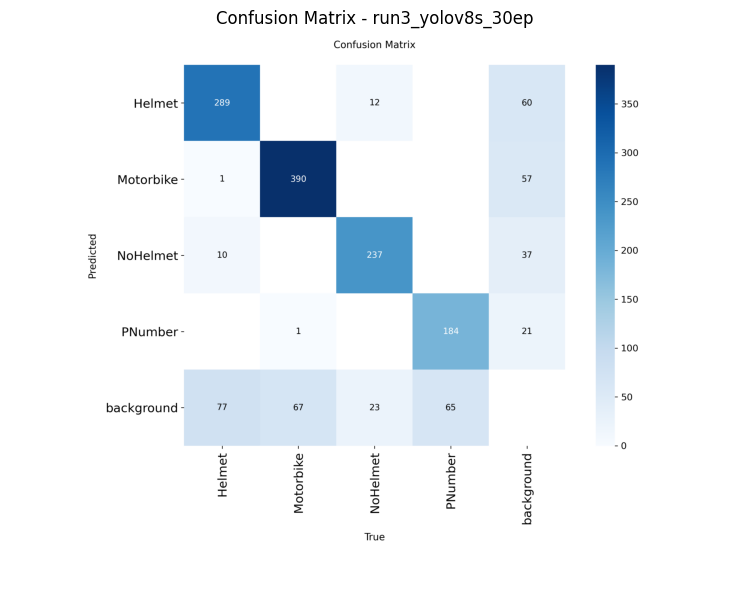

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

conf_path = Path(r"C:\Users\ASUS\runs\runs\run3_yolov8s_30ep\confusion_matrix.png")

if conf_path.exists():
    img = mpimg.imread(str(conf_path))
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix - run3_yolov8s_30ep")
    plt.tight_layout()
    plt.show()
else:
    print(f"Not found: {conf_path}")


## 9. Launch MLflow UI

Run in terminal:
```
mlflow ui --backend-store-uri file:../mlruns
```
Then open `http://127.0.0.1:5000` and screenshot the runs table for B4.